/home/user/anaconda3/envs/kakamega_hazard/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


================ Top Environmental & Spatial Predictors ================
                                       Feature  Random_Forest_Importance  XGBoost_Importance
                  Distance_from_closest_mine_m                  0.031369            0.148007
                                     Soil_type                  0.041230            0.126351
        Distance from closest waste disposal m                  0.073391            0.106336
                                  Clay_percent                  0.038339            0.084425
                                     Longitude                  0.078906            0.062403
Avg_3months_Temperature_before_data_collection                  0.044153            0.056707
                  Distance_from_closest_road_m                  0.086328            0.051567
                                      LATITUDE                  0.073963            0.049751
                 Distance_upstream_waste_pit_m                  0.039443            0.0429

/tmp/ipykernel_23385/3133503307.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='XGBoost_Importance', y='Feature', data=importance_df.sort_values(by='XGBoost_Importance', ascending=True), palette='viridis')


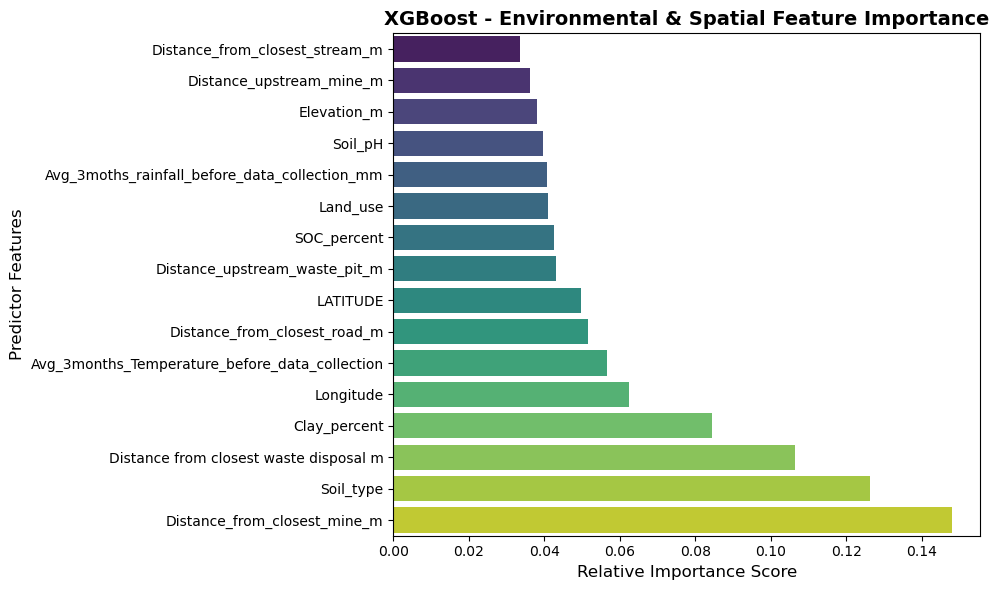

/tmp/ipykernel_23385/3133503307.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Random_Forest_Importance', y='Feature', data=rf_sorted_df, palette='magma')


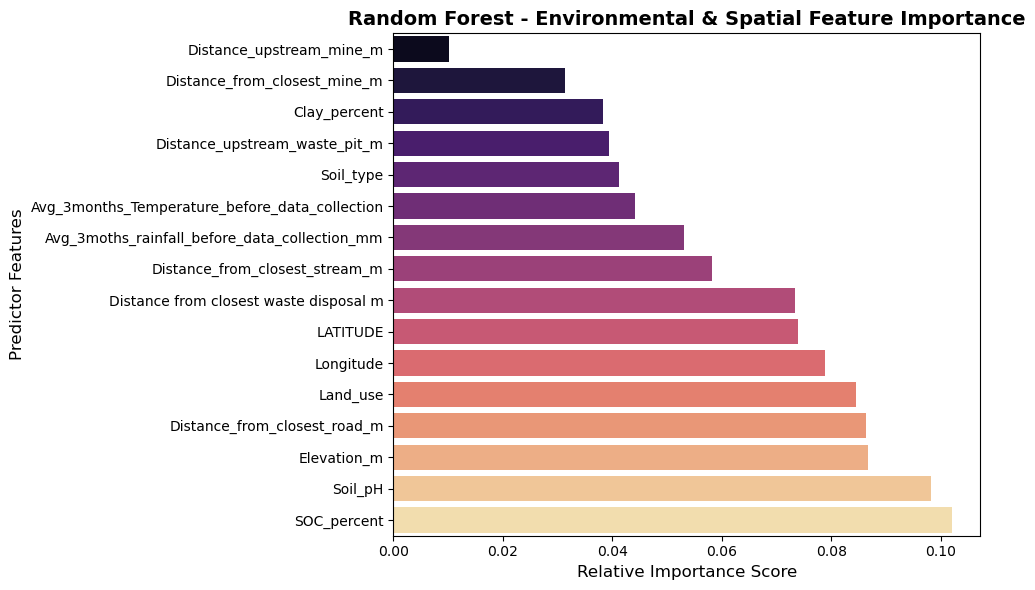


Feature importance charts successfully saved to the 'models/' folder!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 1. Load dataset & prepare features
file_path = 'TRAINING DATA-SOIL.xlsx'
df = pd.read_excel(file_path, sheet_name=0)

for col in ['Land_use', 'Soil_type']:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

target_encoder = LabelEncoder()
df['Overall_class_encoded'] = target_encoder.fit_transform(df['Overall_class'].astype(str))

X = df.drop(columns=['ID', 'Overall_class', 'Overall_class_encoded'])
y = df['Overall_class_encoded']

feature_names = X.columns

# 2. Train Random Forest to extract feature importances
rf_model = RandomForestClassifier(n_estimators=600, max_depth=14, class_weight='balanced', random_state=42)
rf_model.fit(X, y)
rf_importances = rf_model.feature_importances_

# 3. Train XGBoost to extract feature importances
xgb_model = XGBClassifier(n_estimators=600, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='mlogloss')
xgb_model.fit(X, y)
xgb_importances = xgb_model.feature_importances_

# 4. Create a comparison DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Random_Forest_Importance': rf_importances,
    'XGBoost_Importance': xgb_importances
}).sort_values(by='XGBoost_Importance', ascending=False)

print("================ Top Environmental & Spatial Predictors ================")
print(importance_df.to_string(index=False))

# 5. Plot and Save XGBoost Feature Importance Chart
plt.figure(figsize=(10, 6))
sns.barplot(x='XGBoost_Importance', y='Feature', data=importance_df.sort_values(by='XGBoost_Importance', ascending=True), palette='viridis')
plt.title('XGBoost - Environmental & Spatial Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('Predictor Features', fontsize=12)
plt.tight_layout()
plt.savefig('models/xgb_feature_importance.png', dpi=300)
plt.show()

# 6. Plot and Save Random Forest Feature Importance Chart
plt.figure(figsize=(10, 6))
rf_sorted_df = importance_df.sort_values(by='Random_Forest_Importance', ascending=True)
sns.barplot(x='Random_Forest_Importance', y='Feature', data=rf_sorted_df, palette='magma')
plt.title('Random Forest - Environmental & Spatial Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('Predictor Features', fontsize=12)
plt.tight_layout()
plt.savefig('models/rf_feature_importance.png', dpi=300)
plt.show()

print("\nFeature importance charts successfully saved to the 'models/' folder!")